# Classification Metrics: Logistic Regression on the Fish Market Dataset

This notebook rebuilds the classification-evaluation workflow from my STAT 650 final
project into a single, self-contained example. The task: given a fish's physical
dimensions, predict whether it is a **high-value** fish (top quartile by weight). It is a
clean setting to exercise every classification metric end to end — a confusion matrix,
precision / recall / F1, ROC-AUC, and odds-ratio interpretation — on real data instead of
a synthetic toy.

The data is the public [Kaggle *Fish Market* dataset](https://www.kaggle.com/datasets/aungpyaeap/fish-market)
(159 rows, 7 species, weight + five body-dimension measurements). It ships next to this
notebook as `Fish.csv`.

The definitions behind these metrics live in
[Statistics -> Logistic Regression](../../03-statistics/regression/logistic.md); this
notebook is the *applied* layer — computing and reading them on a real model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
)

RANDOM_STATE = 10  # pin a seed so this notebook reproduces the same numbers on every run

df = pd.read_csv("Fish.csv")
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## Clean the data and build the target

One Roach row has `Weight == 0`, which is a data-entry error (a fish with zero mass), so I
drop it. Then I engineer the two derived columns the model uses:

- **`Volume`** = `Length1 x Height x Width` — a size interaction feature.
- **`HighValue`** — the binary target, `1` when a fish's weight is at or above the **75th
  percentile**, else `0`. Using the top quartile makes this a deliberately imbalanced
  problem (~25% positives), which is exactly where accuracy alone starts to mislead and the
  other metrics earn their keep.

In [2]:
df = df[df["Weight"] > 0].copy()          # drop the zero-weight bad row
df["Volume"] = df["Length1"] * df["Height"] * df["Width"]

weight_75th = df["Weight"].quantile(0.75)
df["HighValue"] = (df["Weight"] >= weight_75th).astype(int)

feature_cols = ["Length1", "Length2", "Length3", "Height", "Width", "Volume"]
X = df[feature_cols]
y = df["HighValue"]

print(f"75th-percentile weight cutoff: {weight_75th:.1f} g")
print(f"Class balance: {y.mean():.1%} high-value ({y.sum()} of {len(y)} fish)")

75th-percentile weight cutoff: 650.0 g
Class balance: 25.9% high-value (41 of 158 fish)


## Split, then scale — in that order

The split comes first, and the scaler is fit on the **training set only** before being
applied to the test set. Fitting the scaler on the full dataset would let test-set means
and standard deviations bleed into training — a small but real form of
[data leakage](../leakage-patterns.md). Logistic regression's coefficients (and therefore
the odds ratios below) are only comparable across features once everything is on the same
z-score scale.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train
X_test_scaled = scaler.transform(X_test)         # apply to test

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

Train: 118 rows | Test: 40 rows


## Fit the model and read the classification report

`classification_report` is the one-stop summary: per-class precision, recall, and F1, plus
overall accuracy. Because the positive class (high-value) is the minority, I care most
about its **recall** — of the genuinely valuable fish, how many did the model catch — since
in a purchasing context a missed high-value fish is the expensive mistake.

In [4]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Low value", "High value"]))
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

   Low value       0.97      1.00      0.98        30
  High value       1.00      0.90      0.95        10

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40

Test accuracy: 0.9750
Test ROC-AUC:  0.9900


## Confusion matrix

Every metric above is just an arithmetic combination of these four cells. Reading the
off-diagonal is the fastest way to see *how* a model is wrong: a false positive (a
low-value fish flagged high-value) costs differently than a false negative (a valuable fish
missed).

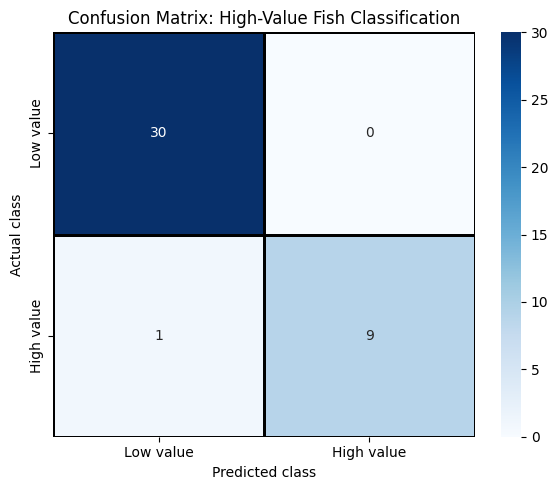

True negatives:  30
False positives: 0
False negatives: 1
True positives:  9


In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low value", "High value"],
            yticklabels=["Low value", "High value"],
            cbar=True, linewidths=1, linecolor="black", ax=ax)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Confusion Matrix: High-Value Fish Classification")
plt.tight_layout()
plt.savefig("../img/confusion-matrix.png", dpi=110, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives:  {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")

## ROC curve and AUC

The confusion matrix is fixed at the default 0.5 probability threshold. The ROC curve
sweeps *every* threshold and plots the true-positive rate against the false-positive rate,
and the area under it (AUC) summarizes how well the model's probability scores separate the
two classes independent of any single cutoff. AUC = 0.5 is coin-flipping; AUC = 1.0 is
perfect separation.

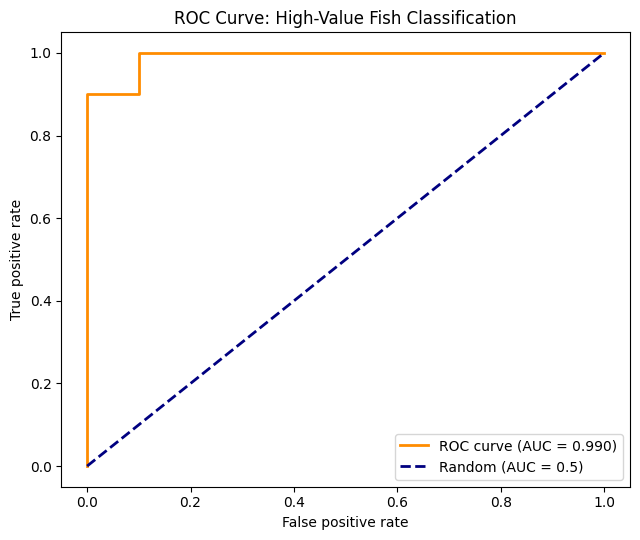

ROC-AUC: 0.9900


In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random (AUC = 0.5)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC Curve: High-Value Fish Classification")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../img/roc-curve.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"ROC-AUC: {auc:.4f}")

## Interpreting the coefficients as odds ratios

Because logistic regression models the **log-odds**, exponentiating a coefficient turns it
into an **odds ratio** — a multiplicative effect that reads in plain language. With the
features standardized, each odds ratio answers: *"per one-standard-deviation increase in
this measurement, the odds of being high-value multiply by X."* That makes the coefficients
directly comparable, so the ranking tells me which body dimension carries the most signal.

In [7]:
coef_df = (
    pd.DataFrame({
        "Feature": feature_cols,
        "Coefficient": log_reg.coef_[0],
        "Odds Ratio": np.exp(log_reg.coef_[0]),
    })
    .sort_values("Odds Ratio", ascending=False)
    .reset_index(drop=True)
)

print(f"Intercept: {log_reg.intercept_[0]:.4f}\n")
print(coef_df.to_string(index=False))

Intercept: -4.6183

Feature  Coefficient  Odds Ratio
 Volume     1.691907    5.429826
  Width     1.517142    4.559175
Length1     0.871148    2.389652
Length2     0.838458    2.312798
Length3     0.734699    2.084855
 Height     0.651565    1.918541


## Takeaways

- **Accuracy alone hides the story.** On a ~75/25 split a model could score 75% just by
  always predicting "low value." The per-class recall in the classification report and the
  confusion matrix are what reveal whether the minority (high-value) class is actually being
  caught.
- **The ROC-AUC is threshold-free.** Accuracy and the confusion matrix are pinned to the
  0.5 cutoff; AUC evaluates the ranking the model produces across all thresholds, which is
  why it is the metric I reach for when comparing models.
- **Odds ratios make the model explainable.** Exponentiating standardized coefficients turns
  a black-box score into "volume is the strongest driver of high-value status," which is the
  kind of statement a business decision can actually rest on.
- **The split-then-scale discipline is non-negotiable.** Fitting the scaler before the split
  leaks test statistics into training — see [Leakage Patterns](../leakage-patterns.md) for
  the full catalogue of ways evaluation quietly lies to you.

For the metric *definitions* behind everything here, see
[Statistics -> Logistic Regression](../../03-statistics/regression/logistic.md). For the
same metrics applied to comparing two different classifiers (Gaussian Naive Bayes vs kNN),
see [Classification Metrics](../classification-metrics.md).